In [1]:
import anndata
import torch
import stPlus

import squidpy as sq
import numpy as np
import scanpy as sc
import pandas as pd

from scipy import sparse
from sklearn.model_selection import KFold
from transpa.eval_util import calc_corr
from transpa.util import expTransImp, leiden_cluster, compute_autocorr, expLocImp
from benchmark import SpaGE_impute, Tangram_impute
import warnings
from sklearn.preprocessing import MinMaxScaler
import os
torch.autograd.detect_anomaly()
warnings.filterwarnings('ignore')

seed = 10
device = torch.device("cuda:3") if torch.cuda.is_available() else torch.device("cpu")

In [2]:
# from matplotlib import pyplot as plt

# spa_adata_sub = spa_adata[spa_adata.obs.Bregma == 0.06, :].copy()
# spa_adata_sub = spa_adata_sub[spa_adata_sub.obs.X < 0, :].copy()
# spa_adata_sub = spa_adata_sub[spa_adata_sub.obs.Y < -2000].copy()
# plt.hist(spa_adata_sub.obs.X, bins=50); plt.show(); plt.hist(spa_adata_sub.obs.Y, bins=50)
# spa_adata_sub.obsm['spatial'] = np.hstack([spa_adata_sub.obs.X.values.reshape(-1,1), spa_adata_sub.obs.Y.values.reshape(-1,1)])
# sc.pl.spatial(spa_adata_sub, basis='spatial', color="Cell_class", spot_size=20)

In [3]:
merfish_path = '../../data/ST/Merfish/merfish.h5ad'
# if os.path.exists(merfish_path):
#     spa_adata = sc.read(merfish_path)
# else:
    # merfish = pd.read_csv('../../data/ST/Merfish/Moffitt_and_Bambah-Mukku_et_al_merfish_all_cells.csv')
merfish = pd.read_csv('../../../data/stPlus/data/SpaGE Datasets/Spatial/MERFISH/Moffitt_and_Bambah-Mukku_et_al_merfish_all_cells.csv')
merfish_1 = merfish.loc[merfish['Animal_ID'] == 1, :]
merfish_1 = merfish_1.loc[merfish.Bregma == 0.06, :]
merfish_1 = merfish_1.loc[merfish_1.Centroid_X < 0, :]
merfish_1 = merfish_1.loc[merfish_1.Centroid_Y < -2000, :]
merfish_1 = merfish_1.loc[merfish_1['Cell_class'] != 'Ambiguous',:]
merfish_meta = merfish_1.iloc[:,0:9]
merfish_data = merfish_1.iloc[:,9:171]
merfish_data = merfish_data.drop(columns = ['Blank_1','Blank_2','Blank_3','Blank_4','Blank_5','Fos'])

spa_adata = anndata.AnnData(merfish_data.values)
spa_adata.obs = merfish_meta
spa_adata.obs.index = spa_adata.obs.index.astype(str)
spa_adata.obs['X'] = merfish_1.Centroid_X.values
spa_adata.obs['Y'] = merfish_1.Centroid_Y.values

spa_adata.var_names = merfish_data.columns.values
spa_adata.var_names_make_unique()
sc.pp.normalize_total(spa_adata)
sc.pp.log1p(spa_adata)
spa_adata.write(merfish_path)


Moffit_path = '../../data/scRNAseq/Moffit/moffit_adata.h5ad'

if os.path.exists(Moffit_path):
    scrna_adata = sc.read(Moffit_path)
else:
    scrna_adata = sc.read_mtx("../../data/scRNAseq/Moffit/GSE113576/matrix.mtx").T
    genes = pd.read_csv('../../data/scRNAseq/Moffit/GSE113576/genes.tsv',sep='\t',header=None).loc[:, 1].values
    barcodes = pd.read_csv('../../data/scRNAseq/Moffit/GSE113576/barcodes.tsv',sep='\t',header=None).loc[:, 0].values

    scrna_adata.var_names = genes
    scrna_adata.obs_names = barcodes
    scrna_adata.var_names_make_unique()
    classes, ct_list = leiden_cluster(scrna_adata)
    cls_key = 'leiden'
    scrna_adata.obs[cls_key] = classes
    sc.pp.filter_genes(scrna_adata, min_cells=10)
    sc.pp.normalize_total(scrna_adata)
    sc.pp.log1p(scrna_adata)
    scrna_adata.write(Moffit_path)
    
spa_adata.var_names_make_unique()
scrna_adata.var_names_make_unique()
ct_list = np.unique(scrna_adata.obs.leiden)
classes = scrna_adata.obs.leiden.values
cls_key = 'leiden'
spa_adata, scrna_adata

(AnnData object with n_obs × n_vars = 5343 × 155
     obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'X', 'Y'
     uns: 'log1p',
 AnnData object with n_obs × n_vars = 31299 × 18646
     obs: 'leiden'
     var: 'n_cells')

In [4]:
raw_spatial_df  = pd.DataFrame(spa_adata.X, columns=spa_adata.var_names)
# raw_scrna_df    = pd.DataFrame.sparse.from_spmatrix(Moffit_adata.X, columns=Moffit_adata.var_names)
raw_scrna_df    = pd.DataFrame(scrna_adata.X.toarray(), columns=scrna_adata.var_names)
raw_shared_gene = np.intersect1d(raw_spatial_df.columns, raw_scrna_df.columns)
valid_genes = np.intersect1d(spa_adata.var_names, scrna_adata.var_names)
raw_spatial_df.shape, raw_scrna_df.shape, raw_shared_gene.shape

((5343, 155), (31299, 18646), (153,))

In [5]:
spa_adata.obsm['spatial'] = np.hstack([spa_adata.obs.X.values.reshape(-1,1), spa_adata.obs.Y.values.reshape(-1,1)])
spa_adata.obsm['spatial'] = MinMaxScaler().fit_transform(spa_adata.obsm['spatial'])
sq.gr.spatial_neighbors(spa_adata,  spatial_key="spatial", key_added="spatial")
sq.gr.spatial_autocorr(
    spa_adata,
    connectivity_key="spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
spa_adata.uns["moranI"]

# # np.digitize(spa_adata.uns["moranI"].I, ), right=False)

# counts, segs = np.histogram(spa_adata.uns["moranI"].I, bins=50)
# # weights_dict = np.exp(1-(counts / counts.sum()))

# weights_dict = [1/count if count else count for count in counts] 
# weights = np.zeros(spa_adata.shape[1]) - 1
# left = segs[0]
# sss = 0
# for ith, right in enumerate(segs[1:]):
#     sel = (left <= spa_adata.uns['moranI'].I.values) & ( spa_adata.uns['moranI'].I.values <= right)
#     sss += sel.sum()
#     weights[sel] = weights_dict[ith]
#     left = right
# weights


,I,pval_norm,var_norm,pval_norm_fdr_bh
Mbp,0.742968,0.000000,0.000063,0.000000
Nnat,0.717612,0.000000,0.000063,0.000000
Sln,0.676180,0.000000,0.000063,0.000000
Myh11,0.501047,0.000000,0.000063,0.000000
Lmod1,0.466496,0.000000,0.000063,0.000000
...,...,...,...,...
Nup62cl,0.023571,0.001357,0.000063,0.001393
Avpr2,0.023122,0.001632,0.000063,0.001665
Kiss1r,0.017665,0.012130,0.000063,0.012289
Gbx2,0.016980,0.015134,0.000063,0.015233


In [6]:
sc_expr = sparse.coo_matrix(raw_scrna_df[raw_shared_gene].values)
sp_expr = raw_spatial_df[raw_shared_gene].values
loc     = spa_adata.obsm['spatial']
sc_loc = expLocImp(sc_expr, 
            sp_expr,
            loc,
            n_neighbors=6,
            l_kernel=2,
            autocorr_method='moranI',
            mapping_lowdim=128,
            lr=1e-4, weight_decay=1e-3, n_epochs=2500,
            device=device,
            seed=seed
            ) 

scrna_adata.obsm["sc_spatial"] = sc_loc # MinMaxScaler().fit_transform(sc_loc)
         

2022-12-24 22:13:38,579 - harmonypy - INFO - Iteration 1 of 10
2022-12-24 22:14:05,756 - harmonypy - INFO - Iteration 2 of 10
2022-12-24 22:14:33,426 - harmonypy - INFO - Iteration 3 of 10
2022-12-24 22:15:01,352 - harmonypy - INFO - Iteration 4 of 10
2022-12-24 22:15:29,274 - harmonypy - INFO - Iteration 5 of 10
2022-12-24 22:15:56,564 - harmonypy - INFO - Iteration 6 of 10
2022-12-24 22:16:20,997 - harmonypy - INFO - Iteration 7 of 10
2022-12-24 22:16:35,668 - harmonypy - INFO - Iteration 8 of 10
2022-12-24 22:16:47,820 - harmonypy - INFO - Converged after 8 iterations
[LocImp] Epoch: 2500/2500, loss: 0.003236: 100%|██████████| 2500/2500 [04:06<00:00, 10.15it/s]


In [7]:
scrna_adata_sub = scrna_adata[:, valid_genes].copy()
scrna_adata_sub.X = scrna_adata_sub.X.toarray()
sq.gr.spatial_neighbors(scrna_adata_sub,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_sub,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)

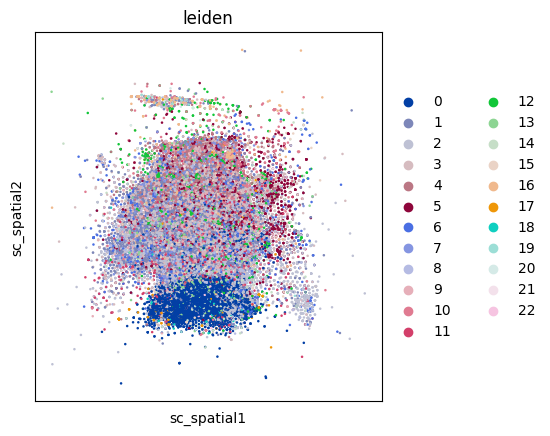

In [8]:
sc.pl.spatial(scrna_adata_sub, basis="sc_spatial", color="leiden", spot_size=0.01)   

(array([  16.,  511., 2044., 7191., 9543., 7143., 3073., 1358.,  408.,
         12.]), array([-0.09508467,  0.0295864 ,  0.15425746,  0.27892852,  0.4035996 ,
        0.52827066,  0.6529417 ,  0.7776128 ,  0.90228385,  1.0269549 ,
        1.151626  ], dtype=float32), <BarContainer object of 10 artists>)


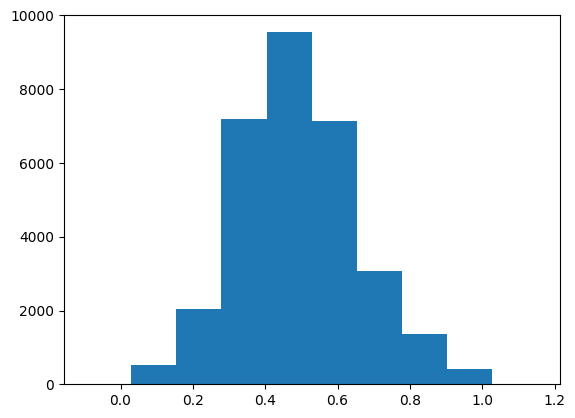

(array([4.000e+00, 6.320e+02, 1.232e+03, 3.398e+03, 5.712e+03, 6.565e+03,
        4.948e+03, 7.921e+03, 8.770e+02, 1.000e+01]),
 array([-0.160033  , -0.02727424,  0.10548452,  0.23824328,  0.37100205,
         0.5037608 ,  0.63651955,  0.76927835,  0.9020371 ,  1.0347959 ,
         1.1675546 ], dtype=float32),
 <BarContainer object of 10 artists>)

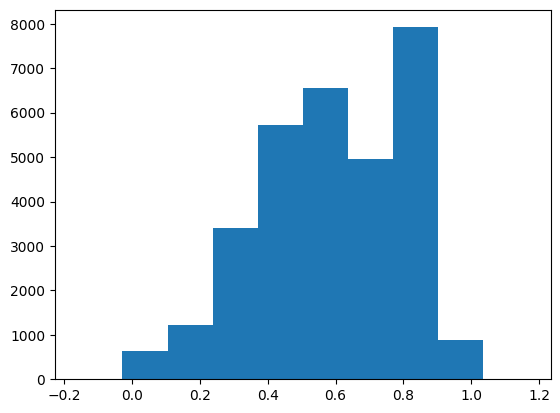

In [9]:
from matplotlib import pyplot as plt
print(plt.hist(sc_loc[:, 0])); plt.show(); plt.hist(sc_loc[:, 1])

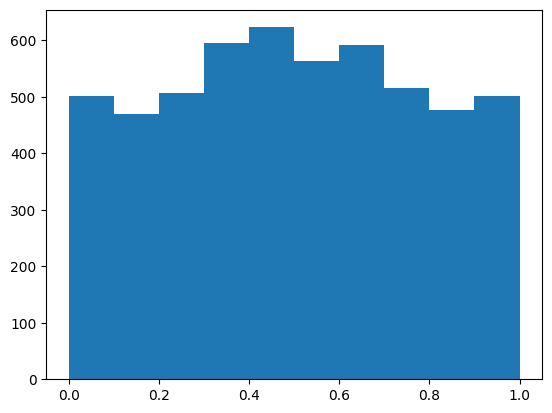

(array([404., 465., 574., 544., 609., 589., 572., 497., 542., 547.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

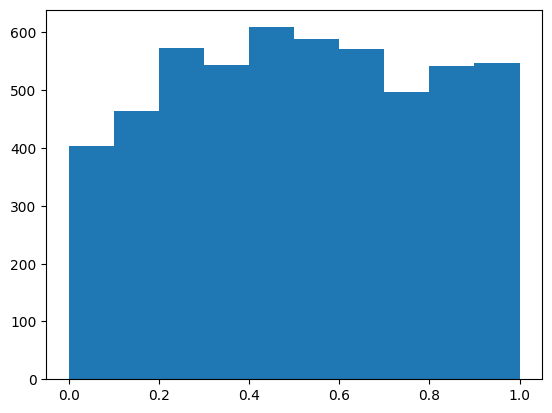

In [10]:
from matplotlib import pyplot as plt
plt.hist(spa_adata.obsm['spatial'][:, 0]); plt.show(); plt.hist(spa_adata.obsm['spatial'][:, 1])

2022-12-24 22:21:22,781 - harmonypy - INFO - Iteration 1 of 10
2022-12-24 22:21:52,620 - harmonypy - INFO - Iteration 2 of 10
2022-12-24 22:22:22,928 - harmonypy - INFO - Iteration 3 of 10
2022-12-24 22:22:50,929 - harmonypy - INFO - Iteration 4 of 10
2022-12-24 22:23:19,147 - harmonypy - INFO - Iteration 5 of 10
2022-12-24 22:23:49,298 - harmonypy - INFO - Iteration 6 of 10
2022-12-24 22:24:14,355 - harmonypy - INFO - Iteration 7 of 10
2022-12-24 22:24:29,944 - harmonypy - INFO - Iteration 8 of 10
2022-12-24 22:24:44,057 - harmonypy - INFO - Converged after 8 iterations


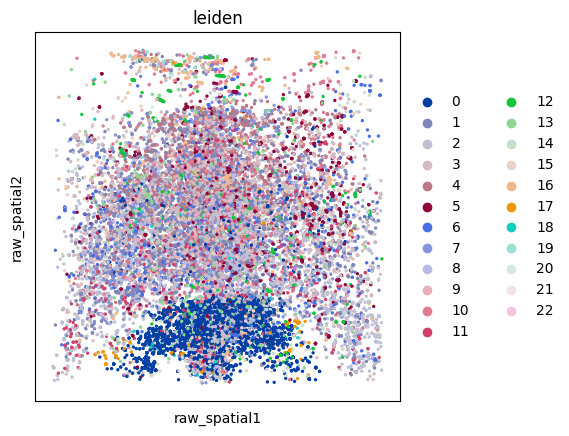

In [11]:
from sklearn.neighbors import  NearestNeighbors
from scipy.special import softmax
spa_adata_sub = spa_adata[:, valid_genes].copy()

# spa_adata_sub.X = spa_adata_sub.X.toarray()
K = 2
adata = sc.AnnData(np.vstack([scrna_adata_sub.X, spa_adata_sub.X]))
adata.obs['batch'] = ["a"] * scrna_adata_sub.shape[0] + ['b'] * spa_adata_sub.shape[0]
sc.pp.pca(adata)
sc.external.pp.harmony_integrate(adata, 'batch')

emb_sc = adata.obsm['X_pca_harmony'][:sc_expr.shape[0], :]
emb_sp = adata.obsm['X_pca_harmony'][sc_expr.shape[0]:, :]
nn = NearestNeighbors(n_neighbors=K, metric='cosine', n_jobs=20)
nn.fit(emb_sp)
dists, nbs = nn.kneighbors(emb_sc, K, True)
sc_loc = np.expand_dims(softmax(-dists, axis=-1),1) @ loc[nbs]



scrna_adata_sub.obsm["raw_spatial"] = sc_loc.squeeze() # MinMaxScaler().fit_transform(sc_loc)
sc.pl.spatial(scrna_adata_sub, basis="raw_spatial", color="leiden", spot_size=0.01)


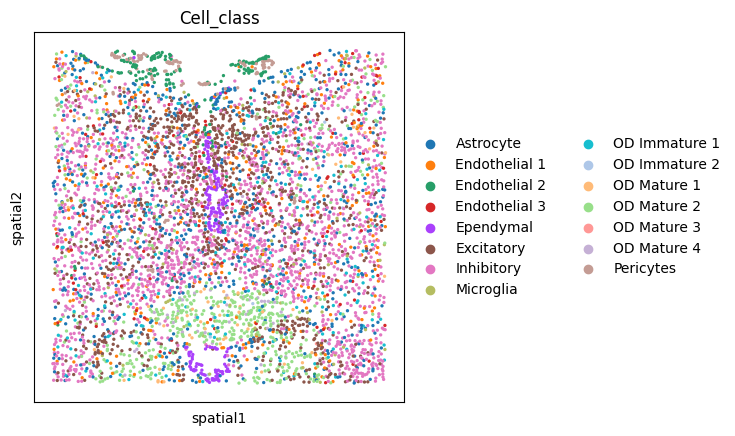

In [12]:
sc.pl.spatial(spa_adata, color="Cell_class", basis="spatial", spot_size=0.01)

In [13]:
sq.gr.spatial_neighbors(spa_adata_sub,  spatial_key="spatial", key_added="spatial")
sq.gr.spatial_autocorr(
    spa_adata_sub,
    connectivity_key="spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
spa_adata_sub.uns["moranI"]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Mbp,0.742968,0.000000,0.000063,0.000000
Nnat,0.717612,0.000000,0.000063,0.000000
Sln,0.676180,0.000000,0.000063,0.000000
Myh11,0.501047,0.000000,0.000063,0.000000
Lmod1,0.466496,0.000000,0.000063,0.000000
...,...,...,...,...
Adora2a,0.023937,0.001165,0.000063,0.001197
Nup62cl,0.023571,0.001357,0.000063,0.001384
Kiss1r,0.017665,0.012130,0.000063,0.012291
Gbx2,0.016980,0.015134,0.000063,0.015234


In [14]:
sq.gr.spatial_neighbors(scrna_adata_sub,  spatial_key="raw_spatial", key_added="raw_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_sub,
    connectivity_key="raw_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
scrna_adata_sub.uns["moranI"].loc[valid_genes]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Ace2,0.126876,0.000000e+00,0.000012,0.000000e+00
Adcyap1,0.130324,0.000000e+00,0.000012,0.000000e+00
Adora2a,0.301076,0.000000e+00,0.000012,0.000000e+00
Aldh1l1,0.127315,0.000000e+00,0.000012,0.000000e+00
Amigo2,0.124518,0.000000e+00,0.000012,0.000000e+00
...,...,...,...,...
Trhr,0.021234,2.159652e-10,0.000012,2.753557e-10
Ttn,0.008766,4.906583e-03,0.000012,5.479615e-03
Ttyh2,0.402595,0.000000e+00,0.000012,0.000000e+00
Ucn3,0.035035,0.000000e+00,0.000012,0.000000e+00


In [15]:
scrna_adata_cp = scrna_adata_sub.copy()
sq.gr.spatial_neighbors(scrna_adata_cp,  spatial_key="sc_spatial", key_added="sc_spatial")
sq.gr.spatial_autocorr(
    scrna_adata_cp,
    connectivity_key="sc_spatial_connectivities",
    mode="moran",
    # n_perms=100,
    n_jobs=10,
)
scrna_adata_cp.uns["moranI"].loc[valid_genes]

,I,pval_norm,var_norm,pval_norm_fdr_bh
Ace2,0.041792,0.000000,0.000011,0.000000
Adcyap1,0.117776,0.000000,0.000011,0.000000
Adora2a,0.106417,0.000000,0.000011,0.000000
Aldh1l1,0.062487,0.000000,0.000011,0.000000
Amigo2,0.115107,0.000000,0.000011,0.000000
...,...,...,...,...
Trhr,0.007345,0.014542,0.000011,0.015136
Ttn,0.011538,0.000310,0.000011,0.000343
Ttyh2,0.269797,0.000000,0.000011,0.000000
Ucn3,0.123668,0.000000,0.000011,0.000000


In [16]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(spa_adata_sub.uns['moranI'].I, scrna_adata_sub.uns['moranI'].loc[spa_adata_sub.uns['moranI'].index].I))
print(mean_squared_error(spa_adata_sub.uns['moranI'].I, scrna_adata_cp.uns['moranI'].loc[spa_adata_sub.uns['moranI'].index].I))

0.024256774098386478
0.008562778783396731


I                   0.501047
pval_norm           0.000000
var_norm            0.000063
pval_norm_fdr_bh    0.000000
Name: Myh11, dtype: float64
AnnData object with n_obs × n_vars = 5343 × 1
    obsm: 'spatial'


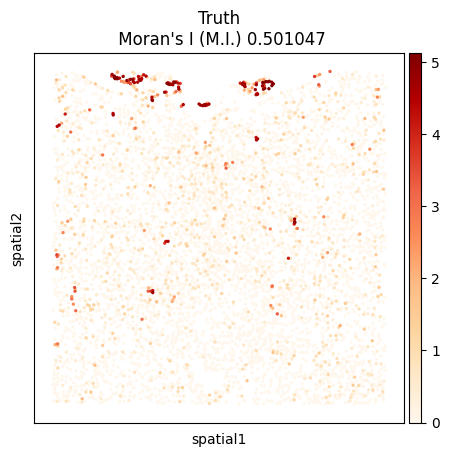

I                   0.581083
pval_norm           0.000000
var_norm            0.000012
pval_norm_fdr_bh    0.000000
Name: Myh11, dtype: float64
AnnData object with n_obs × n_vars = 31299 × 1
    obsm: 'sc_spatial', 'raw_spatial'


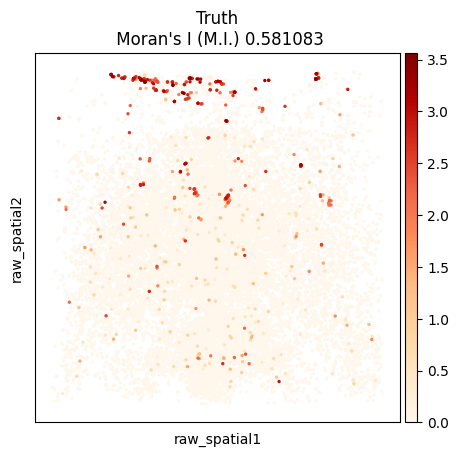

I                   0.434132
pval_norm           0.000000
var_norm            0.000011
pval_norm_fdr_bh    0.000000
Name: Myh11, dtype: float64
AnnData object with n_obs × n_vars = 31299 × 1
    obsm: 'sc_spatial', 'raw_spatial'


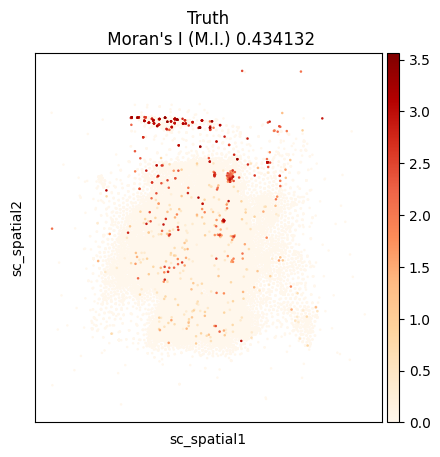

In [17]:
def plot(gene, spa_adata, spa_key):
    exprs = [spa_adata[:, gene].X.toarray().flatten()]
    titles = [f"Truth\n Moran's I (M.I.) {spa_adata.uns['moranI'].loc[gene].I:.6f}"]
    # sc.pl.spatial(spa_adata, color=[gene], spot_size=0.1, title='Truth')
    print(spa_adata.uns['moranI'].loc[gene])
    
    tmp_adata = sc.AnnData(np.array(exprs).T)
    tmp_adata.obsm = spa_adata.obsm
    tmp_adata.var_names = titles
    
    print(tmp_adata)
    sc.pl.spatial(tmp_adata, color=titles, basis=spa_key, spot_size=0.01, title=titles, color_map='OrRd')
plot("Myh11", spa_adata_sub, spa_key='spatial')
plot("Myh11", scrna_adata_sub, spa_key='raw_spatial')
plot("Myh11", scrna_adata_cp, spa_key='sc_spatial')

I                   0.016980
pval_norm           0.015134
var_norm            0.000063
pval_norm_fdr_bh    0.015234
Name: Gbx2, dtype: float64
AnnData object with n_obs × n_vars = 5343 × 1
    obsm: 'spatial'


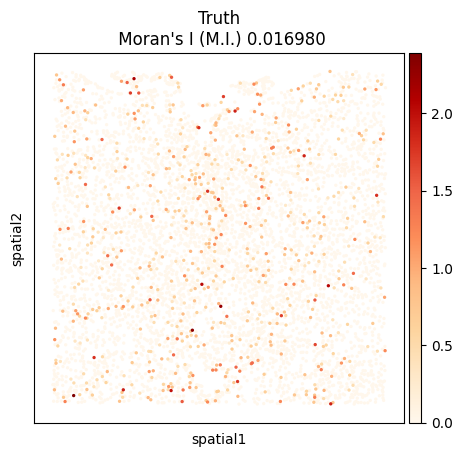

I                   0.034031
pval_norm           0.000000
var_norm            0.000012
pval_norm_fdr_bh    0.000000
Name: Gbx2, dtype: float64
AnnData object with n_obs × n_vars = 31299 × 1
    obsm: 'sc_spatial', 'raw_spatial'


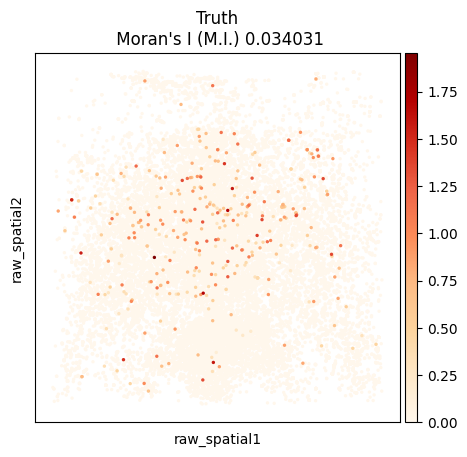

I                   0.014388
pval_norm           0.000010
var_norm            0.000011
pval_norm_fdr_bh    0.000011
Name: Gbx2, dtype: float64
AnnData object with n_obs × n_vars = 31299 × 1
    obsm: 'sc_spatial', 'raw_spatial'


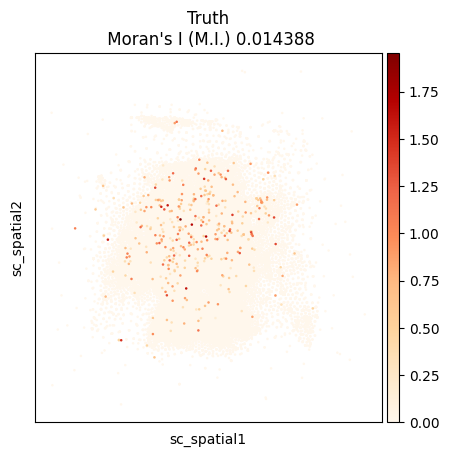

In [18]:
plot("Gbx2", spa_adata_sub, spa_key='spatial')
plot("Gbx2", scrna_adata_sub, spa_key='raw_spatial')
plot("Gbx2", scrna_adata_cp, spa_key='sc_spatial')

I                   0.676180
pval_norm           0.000000
var_norm            0.000063
pval_norm_fdr_bh    0.000000
Name: Sln, dtype: float64
AnnData object with n_obs × n_vars = 5343 × 1
    obsm: 'spatial'


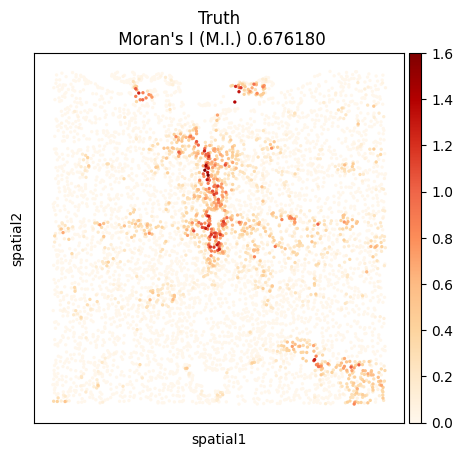

I                   0.369450
pval_norm           0.000000
var_norm            0.000012
pval_norm_fdr_bh    0.000000
Name: Sln, dtype: float64
AnnData object with n_obs × n_vars = 31299 × 1
    obsm: 'sc_spatial', 'raw_spatial'


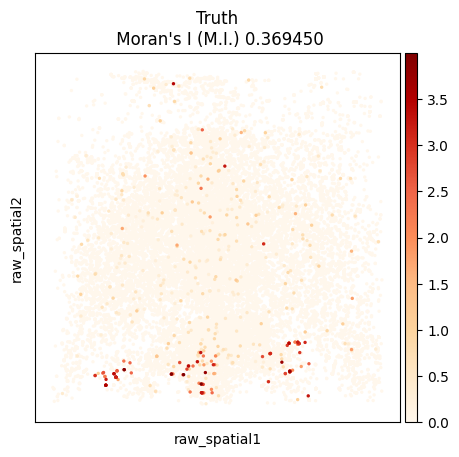

I                   0.384803
pval_norm           0.000000
var_norm            0.000011
pval_norm_fdr_bh    0.000000
Name: Sln, dtype: float64
AnnData object with n_obs × n_vars = 31299 × 1
    obsm: 'sc_spatial', 'raw_spatial'


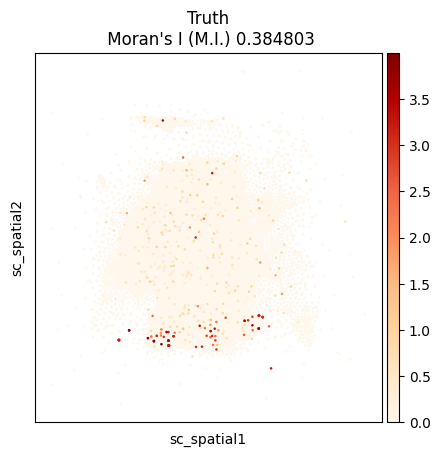

In [19]:
plot("Sln", spa_adata_sub, spa_key='spatial')
plot("Sln", scrna_adata_sub, spa_key='raw_spatial')
plot("Sln", scrna_adata_cp, spa_key='sc_spatial')

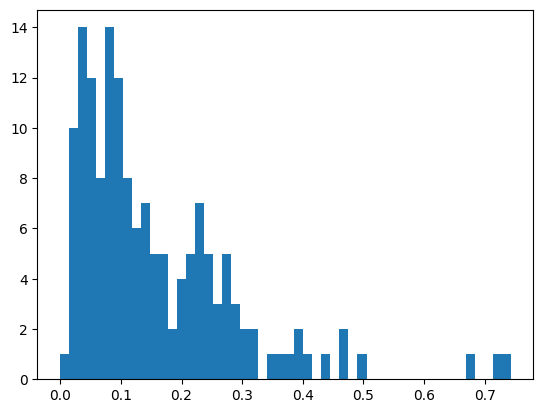

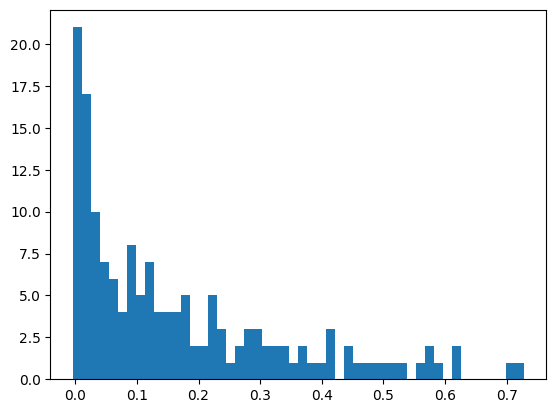

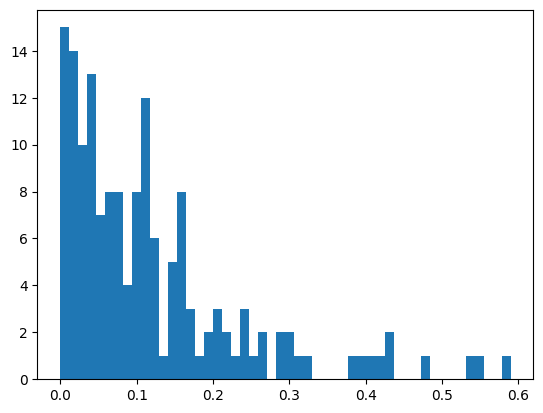

In [20]:
plt.hist(spa_adata_sub.uns['moranI'].I, bins=50, ); plt.show()
plt.hist(scrna_adata_sub.uns['moranI'].I, bins=50); plt.show()
plt.hist(scrna_adata_cp.uns['moranI'].I, bins=50); plt.show()